In this file we will select some variables and look how they behave

under this text we made a dataframe of the gold_match.csv and explore the data that is in it. We look at correlations between different variables that we think are having an influence on the amount of people showing up to a home game at OHL Leuven

In [56]:
import pandas as pd
df = pd.read_csv('data/gold_match.csv')
df['match_date'] = pd.to_datetime(df['match_date'])
df['day_of_week'] = df['match_date'].dt.day_name()
df_home = df[df["is_home_match"] == True]
df.head(10)

,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,winner,result_home,goals_home_ht,goals_away_ht,goals_home_ft,goals_away_ft,is_home_match,last_result_vs_opponent,tickets_scanned,day_of_week
0,d0te6swsv2y99ywgugc2utbmc,2022-07-23,18:15:00,2022-07-23Z,16:15:00Z,1.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,away,L,0,0,0,2,False,L 1-2,NaN,Saturday
1,d256yo3eng04m0fu7b4sl7wno,2022-07-30,18:15:00,2022-07-30Z,16:15:00Z,2.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,home,W,1,0,2,0,True,NaN,5565.0,Saturday
2,d3pqkck2grzx98jg4sofhp8us,2022-08-07,21:00:00,2022-08-07Z,19:00:00Z,3.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,home,W,2,1,4,2,False,L 0-1,NaN,Sunday
3,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,18:30:00,2022-08-14Z,16:30:00Z,4.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,away,L,0,2,0,3,True,L 1-4,7440.0,Sunday
4,d5htdqmc8w72upys41sfxhfkk,2022-08-21,18:30:00,2022-08-21Z,16:30:00Z,5.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,away,L,0,2,1,3,False,W 2-1,NaN,Sunday
5,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,18:15:00,2022-08-27Z,16:15:00Z,6.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,home,W,0,1,2,1,True,W 3-1,4489.0,Saturday
6,d700mwu32x772ns4veqq32yhg,2022-09-04,13:30:00,2022-09-04Z,11:30:00Z,7.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,draw,D,0,1,2,2,False,D 0-0,NaN,Sunday
7,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,20:45:00,2022-09-10Z,18:45:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,home,W,1,1,3,2,True,W 3-0,4508.0,Saturday
8,d9pbl588401et3engzzakcfmc,2022-09-17,16:00:00,2022-09-17Z,14:00:00Z,9.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,draw,D,0,0,0,0,False,L 0-2,NaN,Saturday
9,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,16:00:00,2022-10-01Z,14:00:00Z,10.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,away,L,0,2,0,3,True,L 1-4,6290.0,Saturday


df_home is all the home matches that are in the dataset we also created a extra column with the day of the week

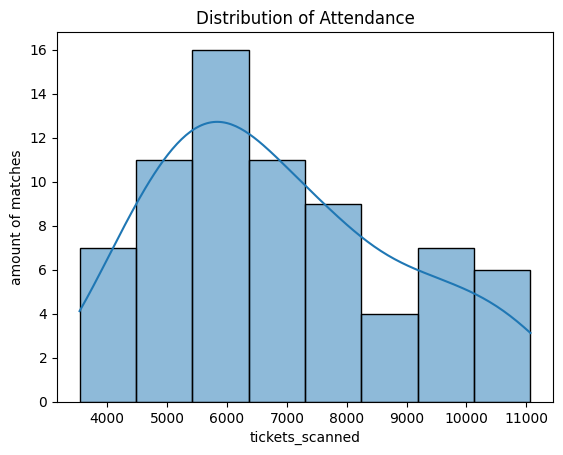

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_home['tickets_scanned'], kde=True)
plt.title("Distribution of Attendance")
plt.ylabel("amount of matches")
plt.show()

This is a visualisation about the attendance of the matches. We want to look at extrememes, see why they are this low or high. You can see under this text that we search why the attendence is like this are like this.

In [58]:
low_att = df_home[df_home['tickets_scanned'] < 5000]
high_att = df_home[df_home['tickets_scanned'] > 9000]
low_att.info()


<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 5 to 130
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   match_id                 13 non-null     object        
 1   match_date               13 non-null     datetime64[ns]
 2   kickoff_time_local       13 non-null     object        
 3   match_date_utc           13 non-null     object        
 4   kickoff_time_utc         13 non-null     object        
 5   matchday                 13 non-null     float64       
 6   competition_id           13 non-null     object        
 7   competition_name         13 non-null     object        
 8   season                   13 non-null     object        
 9   season_id                13 non-null     object        
 10  stage                    13 non-null     object        
 11  home_team_id             13 non-null     object        
 12  home_team                13 non-null     o

In [59]:
high_att.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 26 to 89
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   match_id                 14 non-null     object        
 1   match_date               14 non-null     datetime64[ns]
 2   kickoff_time_local       14 non-null     object        
 3   match_date_utc           14 non-null     object        
 4   kickoff_time_utc         14 non-null     object        
 5   matchday                 14 non-null     float64       
 6   competition_id           14 non-null     object        
 7   competition_name         14 non-null     object        
 8   season                   14 non-null     object        
 9   season_id                14 non-null     object        
 10  stage                    14 non-null     object        
 11  home_team_id             14 non-null     object        
 12  home_team                14 non-null     o

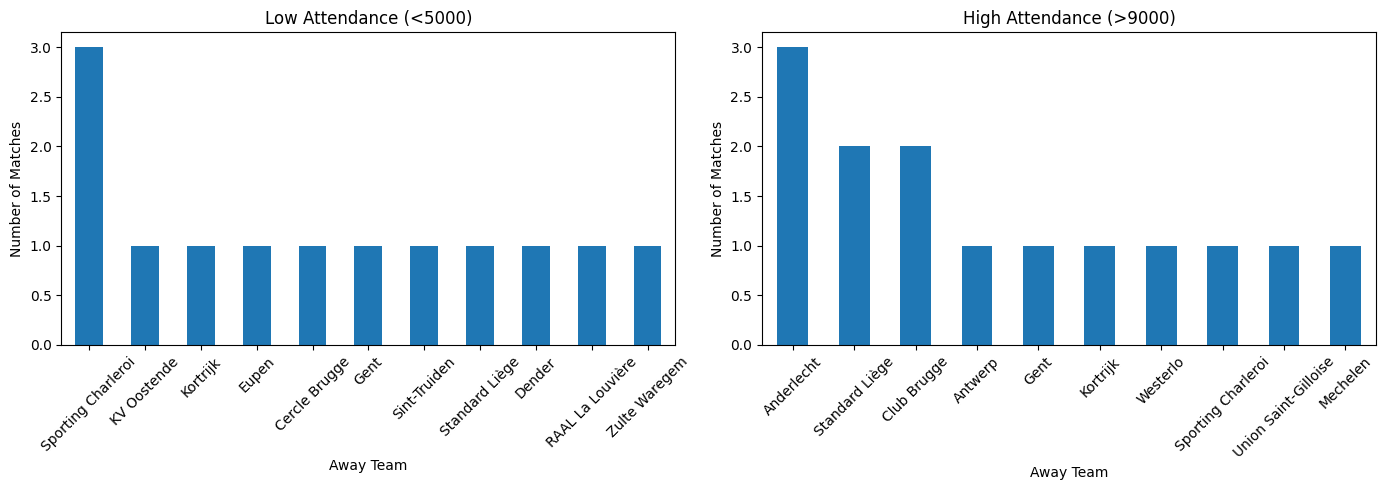

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Low attendance
low_att['away_team'].value_counts().plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Low Attendance (<5000)')
axes[0].set_xlabel('Away Team')
axes[0].set_ylabel('Number of Matches')
axes[0].tick_params(axis='x', rotation=45)

# High attendance
high_att['away_team'].value_counts().plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('High Attendance (>9000)')
axes[1].set_xlabel('Away Team')
axes[1].set_ylabel('Number of Matches')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

We created 2 dataframes 1 with an low attendacne <5000 and another high attendance >9000. On the left You can see the amount of times ohl played against teams with an attendance smaller than 5000. Sporting Charleroi has 3 matches with an low attendance. On the other hand there are a lot of Anderlecht supporters in Leuven because there are 3 matches ohl played against them with an high attendance.

In [61]:
low_att['kickoff_time_local'].describe()


count           13
unique           7
top       16:00:00
freq             5
Name: kickoff_time_local, dtype: object

In [62]:
high_att['kickoff_time_local'].describe()

count           14
unique           4
top       18:15:00
freq             5
Name: kickoff_time_local, dtype: object

In [63]:
df_home['attendance_group'] = 'normal'

df_home.loc[df_home['tickets_scanned'] < 5000, 'attendance_group'] = 'low'
df_home.loc[df_home['tickets_scanned'] > 9000, 'attendance_group'] = 'high'


C:\Users\elian\AppData\Local\Temp\ipykernel_29676\2504991527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_home['attendance_group'] = 'normal'


C:\Users\elian\AppData\Local\Temp\ipykernel_29676\3617532741.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_home['kickoff_time_local'] = pd.to_datetime(df_home['kickoff_time_local'])
C:\Users\elian\AppData\Local\Temp\ipykernel_29676\3617532741.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_home['kickoff_time_local'] = pd.to_datetime(df_home['kickoff_time_local'])
C:\Users\elian\AppData\Local\Temp\ipykernel_29676\3617532741.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

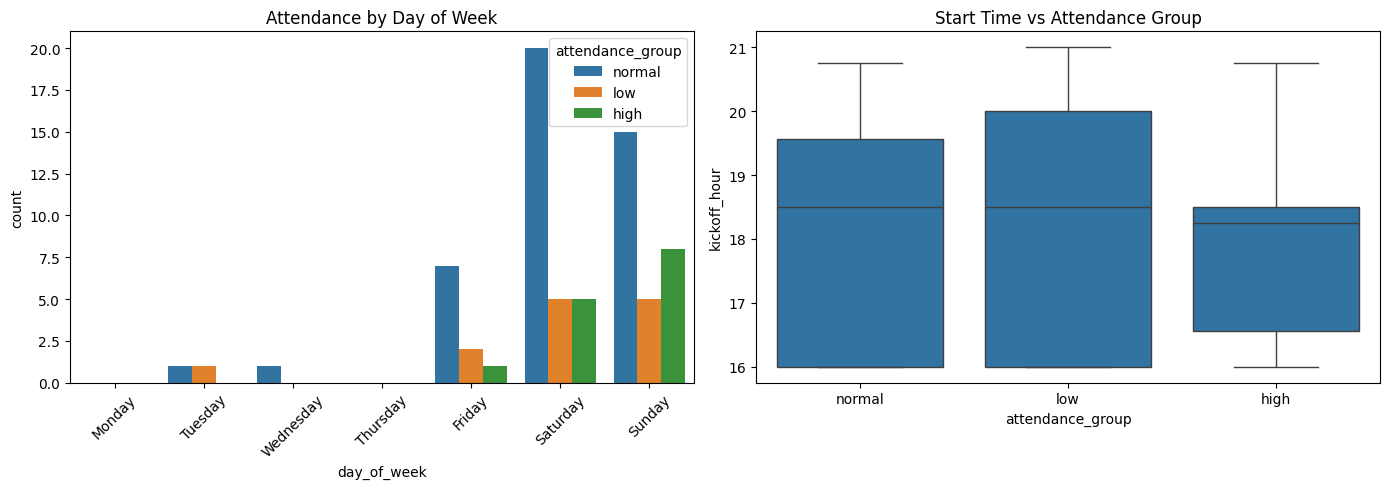

In [64]:
# Create 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Day of week
order_weeks = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df_home, x='day_of_week', hue='attendance_group', ax=axes[0], order=order_weeks)
axes[0].set_title('Attendance by Day of Week')
axes[0].tick_params(axis='x', rotation=45)

#make the kickoff time local a datetime object
df_home['kickoff_time_local'] = pd.to_datetime(df_home['kickoff_time_local'])

df_home['kickoff_hour'] = (
    df_home['kickoff_time_local'].dt.hour +
    df_home['kickoff_time_local'].dt.minute / 60
)

# 2. Start time
sns.boxplot(data=df_home, x='attendance_group', y='kickoff_hour', ax=axes[1])
axes[1].set_title('Start Time vs Attendance Group')



plt.tight_layout()
plt.show()

The left graph tels us a lot about what day of the week there are a lot of people. Sunday is the best day with 8 matches that have a high attendance. Monday and thursday we dont have any data about those games -> no games on these days. only 2 matches on tuesday and 1 on wednesday.

On the right you see 3 boxplots that explain what time the attendance group shows up. For the games where high attendence is it starts between 16:30 and 18:30 so we can conclude that later games have less show-ups.

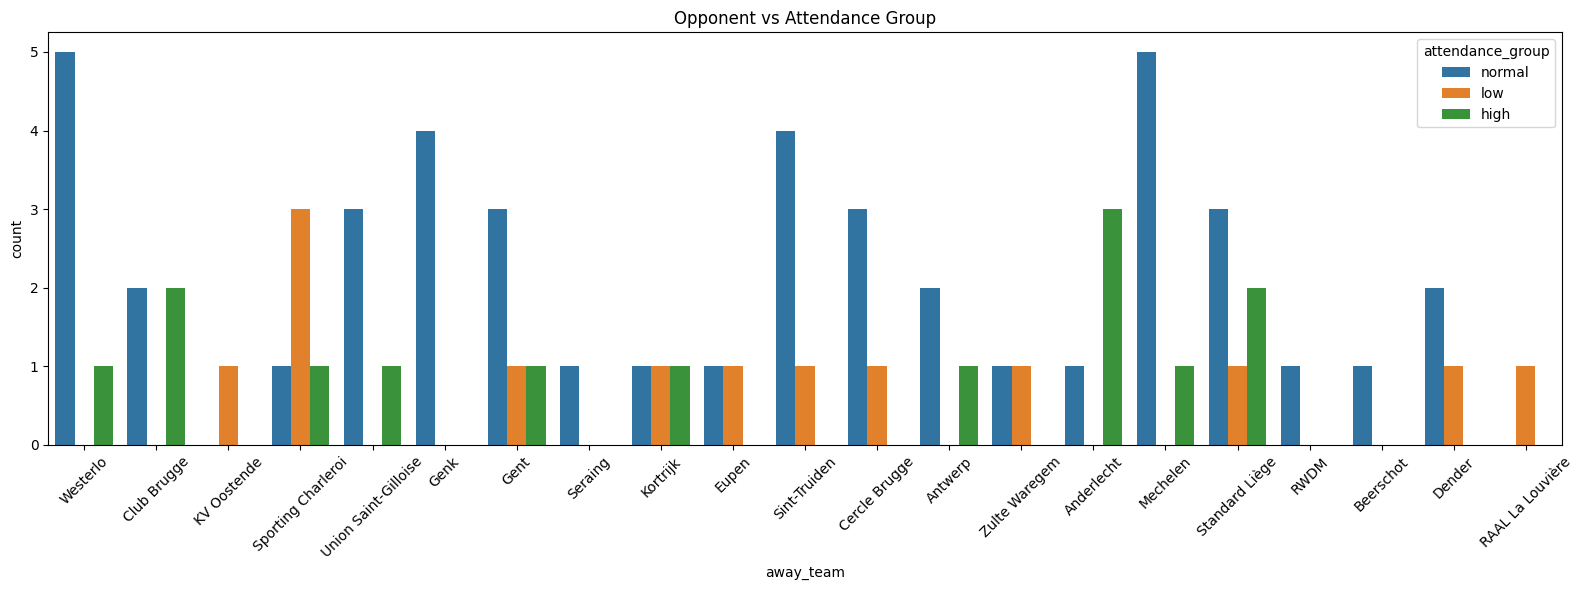

In [65]:
# 3. Opponent
plt.figure(figsize=(16, 6))  # increase width

sns.countplot(data=df_home, x='away_team', hue='attendance_group')
plt.title('Opponent vs Attendance Group')
plt.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In this graph you see every home game ohl played and what group of attendance they got. It is easy to see what games have a lower and higher attendance.

We are changing the dataset so that we can look at the previous results and look how that influences the attendance

In [ ]:
df = df.sort_values('match_date')
df['prev_is_home'] = df['is_home_match'].shift(1)
df['prev_result'] = df['winner'].shift(1)

# Filter for home matches that were preceded by an away match
df_home_after_away = df[
    (df['is_home_match'] == True) &
    (df['prev_is_home'] == False)
].copy()

#extract the first letter of the previous result to get W, L, D
df_home_after_away['prev_result_letter'] = (
    df_home_after_away['last_result_vs_opponent'].str[0]
)

df_home_after_away['prev_result_clean'] = df_home_after_away['prev_result_letter'].map({
    'W': 'win',
    'L': 'loss',
    'D': 'draw'
})

df_home_after_away.head()


,match_id,match_date,kickoff_time_local,match_date_utc,kickoff_time_utc,matchday,competition_id,competition_name,season,season_id,...,goals_home_ft,goals_away_ft,is_home_match,last_result_vs_opponent,tickets_scanned,day_of_week,prev_is_home,prev_result,prev_result_letter,prev_result_clean
1,d256yo3eng04m0fu7b4sl7wno,2022-07-30,18:15:00,2022-07-30Z,16:15:00Z,2.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,2,0,True,NaN,5565.0,Saturday,False,away,NaN,NaN
3,d4mn5ksbxuvnaww4pmommxhqs,2022-08-14,18:30:00,2022-08-14Z,16:30:00Z,4.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,0,3,True,L 1-4,7440.0,Sunday,False,home,L,loss
5,d65hmi7sq03yzr5he1k7ypus4,2022-08-27,18:15:00,2022-08-27Z,16:15:00Z,6.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,2,1,True,W 3-1,4489.0,Saturday,False,away,W,win
7,d80mkemezkz16bqh6lbn8tlhw,2022-09-10,20:45:00,2022-09-10Z,18:45:00Z,8.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,3,2,True,W 3-0,4508.0,Saturday,False,draw,W,win
9,dak40etbhbqsr1nxyt50qcg0k,2022-10-01,16:00:00,2022-10-01Z,14:00:00Z,10.0,4zwgbb66rif2spcoeeol2motx,Belgian Jupiler Pro League,2022/2023,5wj8l9y4s3484k6puwup793pw,...,0,3,True,L 1-4,6290.0,Saturday,False,draw,L,loss


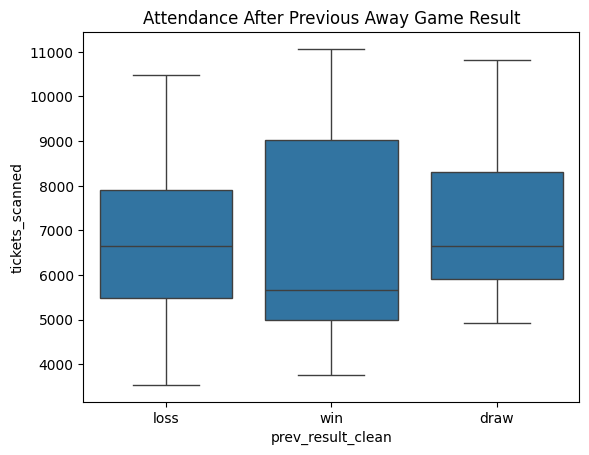

In [82]:
df_home_after_away = df_home_after_away.dropna(subset=['prev_result_clean'])

sns.boxplot(
    data=df_home_after_away,
    x='prev_result_clean',
    y='tickets_scanned'
)

plt.title("Attendance After Previous Away Game Result")
plt.show()

this is a boxplot and we can see that more people will come when we won againts that team the previous match